In [2]:
from pathlib import Path

# Find repo root
REPO_ROOT = Path.cwd()
while REPO_ROOT.name != "masters-project" and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent

if REPO_ROOT.name != "masters-project":
    raise RuntimeError("Could not find repo root folder named 'masters-project'.")

# Base path (raw + processed stay here)
AZURE_BASE = REPO_ROOT / "data" / "raw" / "azure"

# Dataset
AZURE_RAW_DIR = AZURE_BASE / "2023Dataset"

DATA_PROCESSED = AZURE_BASE / "processed"

REPORTS_EVAL = REPO_ROOT / "reports" / "eval" / "splitwise"

# Subfolders
FIG_DIR = REPORTS_EVAL / "figures"
TABLE_DIR = REPORTS_EVAL
CACHE_DIR = REPORTS_EVAL / "cache"
LOG_DIR = REPORTS_EVAL / "logs"

# Ensure dirs
for p in [DATA_PROCESSED, FIG_DIR, TABLE_DIR, CACHE_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Files
CODE_PATH = AZURE_RAW_DIR / "AzureLLMInferenceTrace_code.csv"
CONV_PATH = AZURE_RAW_DIR / "AzureLLMInferenceTrace_conv.csv"

# Debug
print("Azure dataset path:", AZURE_RAW_DIR)
print("Code exists:", CODE_PATH.exists())
print("Conv exists:", CONV_PATH.exists())

print("\nFinal reports will be saved to:", REPORTS_EVAL)

Azure dataset path: /Users/meghanakoti/masterproject/masters-project/data/raw/azure/2023Dataset
Code exists: True
Conv exists: True

Final reports will be saved to: /Users/meghanakoti/masterproject/masters-project/reports/eval/splitwise


Code DF shape: (8819, 3)
Conv DF shape: (19366, 3)

Code DF columns: ['TIMESTAMP', 'ContextTokens', 'GeneratedTokens']
Conv DF columns: ['TIMESTAMP', 'ContextTokens', 'GeneratedTokens']

===== Code Dataset =====

ContextTokens stats:
count    8819.000000
mean     2047.848282
std      1973.877282
min         3.000000
50%      1469.000000
90%      5187.600000
95%      7303.300000
99%      7436.000000
max      7437.000000
Name: ContextTokens, dtype: float64

GeneratedTokens stats:
count    8819.000000
mean       27.882526
std        59.862250
min         6.000000
50%        13.000000
90%        55.000000
95%        90.000000
99%       251.460000
max      1899.000000
Name: GeneratedTokens, dtype: float64

Code Output/Prompt Ratio Stats:
count    8819.000000
mean        0.089700
std         0.504192
min         0.000807
50%         0.010892
90%         0.143132
95%         0.302712
99%         1.156374
max        16.533333
Name: PromptOutputRatio, dtype: float64


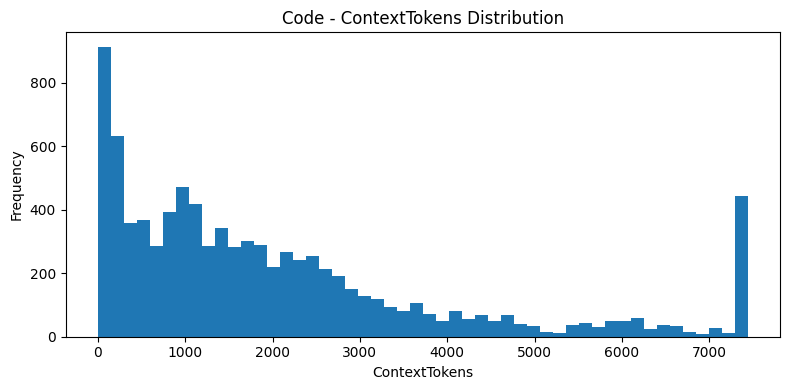


===== Conversation Dataset =====

ContextTokens stats:
count    19366.000000
mean      1154.697408
std       1108.822564
min          2.000000
50%       1020.000000
90%       2734.500000
95%       4083.000000
99%       4142.000000
max      14050.000000
Name: ContextTokens, dtype: float64

GeneratedTokens stats:
count    19366.000000
mean       211.125942
std        162.870478
min          7.000000
50%        129.000000
90%        424.000000
95%        451.000000
99%        601.000000
max       1000.000000
Name: GeneratedTokens, dtype: float64

Conversation Output/Prompt Ratio Stats:
count    19366.000000
mean         0.429647
std          1.377130
min          0.002776
50%          0.279188
90%          0.592170
95%          0.947260
99%          4.981944
max         46.500000
Name: PromptOutputRatio, dtype: float64


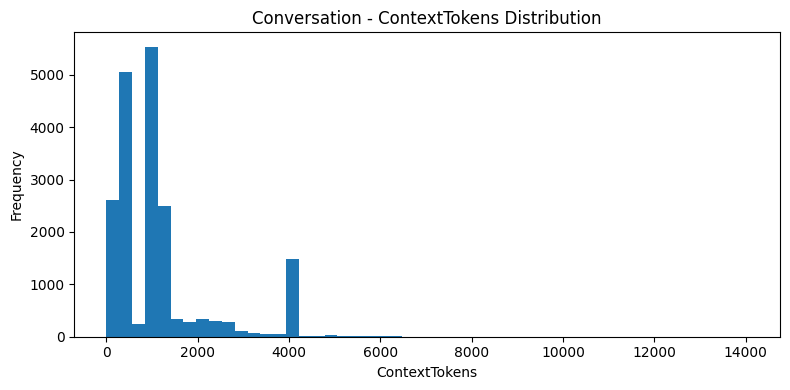

In [3]:
# ------------------------------------------------------------
# STEP 2A: Raw EDA
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt

code_df = pd.read_csv(CODE_PATH)
conv_df = pd.read_csv(CONV_PATH)

print("Code DF shape:", code_df.shape)
print("Conv DF shape:", conv_df.shape)

# 🔹 Check columns (important for avoiding next errors)
print("\nCode DF columns:", code_df.columns.tolist())
print("Conv DF columns:", conv_df.columns.tolist())


# 🔹 EDA Loop
for name, df in [("code", code_df), ("conversation", conv_df)]:
    label = name.capitalize()

    print(f"\n===== {label} Dataset =====")

    # --- Basic stats ---
    print("\nContextTokens stats:")
    print(df["ContextTokens"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

    print("\nGeneratedTokens stats:")
    print(df["GeneratedTokens"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

    # --- Output-to-prompt ratio ---
    df["PromptOutputRatio"] = df["GeneratedTokens"] / df["ContextTokens"].replace(0, 1)

    print(f"\n{label} Output/Prompt Ratio Stats:")
    print(df["PromptOutputRatio"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

    # --- ContextTokens distribution ---
    plt.figure(figsize=(8, 4))
    plt.hist(df["ContextTokens"], bins=50)
    plt.title(f"{label} - ContextTokens Distribution")
    plt.xlabel("ContextTokens")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()
    plt.close()


===== Code TotalTokens Analysis =====

TotalTokens stats:
count    8819.000000
mean     2075.730808
std      1974.853759
min        12.000000
50%      1493.000000
90%      5207.800000
95%      7331.300000
99%      7461.820000
max      7841.000000
Name: TotalTokens, dtype: float64


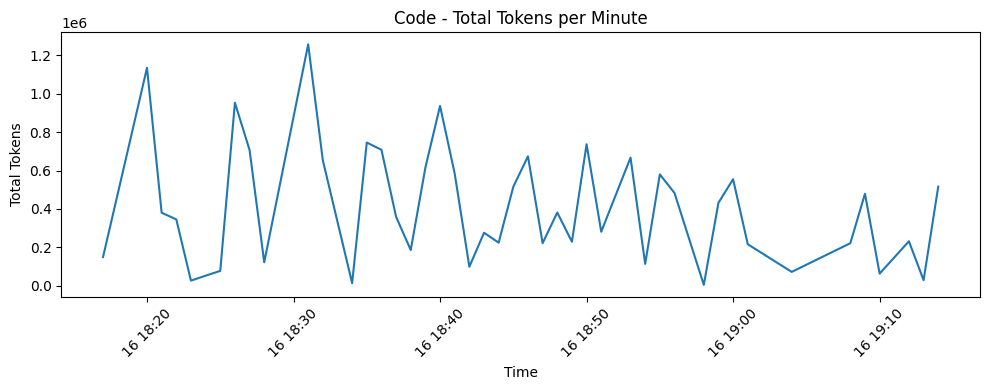


===== Conversation TotalTokens Analysis =====

TotalTokens stats:
count    19366.000000
mean      1365.823350
std       1102.467066
min         64.000000
50%       1412.000000
90%       2819.500000
95%       4136.000000
99%       4259.000000
max      14089.000000
Name: TotalTokens, dtype: float64


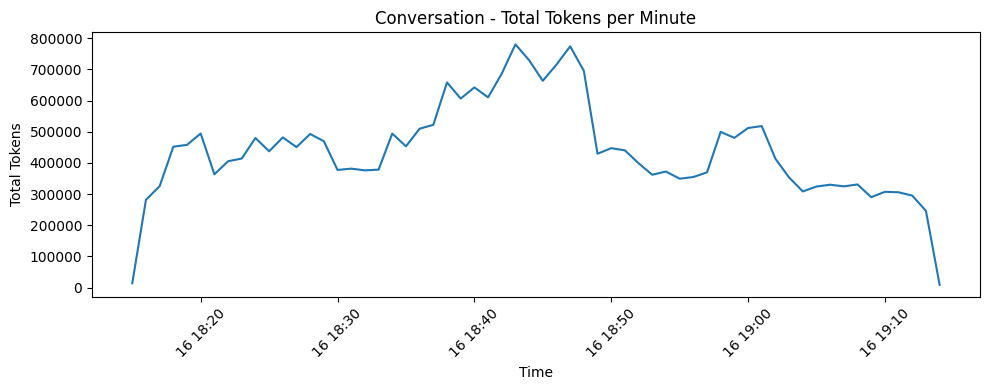


Saved TotalTokens summary:
/Users/meghanakoti/masterproject/masters-project/reports/eval/splitwise/azure_llm_total_tokens_summary.csv


In [4]:
# ------------------------------------------------------------
# STEP 2B: TotalTokens EDA (keep only essential outputs)
# ------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt

TOTAL_STATS_PATH = TABLE_DIR / "azure_llm_total_tokens_summary.csv"

total_rows = []

for name, df in [("code", code_df), ("conversation", conv_df)]:
    label = name.capitalize()

    # Convert required columns
    df["ContextTokens"] = pd.to_numeric(df["ContextTokens"], errors="coerce")
    df["GeneratedTokens"] = pd.to_numeric(df["GeneratedTokens"], errors="coerce")
    df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"], errors="coerce")

    # Remove invalid rows
    df = df.dropna(subset=["ContextTokens", "GeneratedTokens", "TIMESTAMP"]).copy()

    # Create TotalTokens
    df["TotalTokens"] = df["ContextTokens"] + df["GeneratedTokens"]

    # Create minute column
    df["minute"] = df["TIMESTAMP"].dt.floor("min")

    print(f"\n===== {label} TotalTokens Analysis =====")

    # Summary stats
    total_stats = df["TotalTokens"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])
    print("\nTotalTokens stats:")
    print(total_stats)

    total_rows.append({
        "dataset": name,
        "count": total_stats["count"],
        "mean": total_stats["mean"],
        "std": total_stats["std"],
        "min": total_stats["min"],
        "p50": total_stats["50%"],
        "p90": total_stats["90%"],
        "p95": total_stats["95%"],
        "p99": total_stats["99%"],
        "max": total_stats["max"],
    })

    # Tokens per minute
    tokens_per_min = df.groupby("minute")["TotalTokens"].sum()

    plt.figure(figsize=(10, 4))
    plt.plot(tokens_per_min.index, tokens_per_min.values)
    plt.title(f"{label} - Total Tokens per Minute")
    plt.xlabel("Time")
    plt.ylabel("Total Tokens")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}_tokens_per_minute.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

# Save summary table
total_summary_df = pd.DataFrame(total_rows)
total_summary_df.to_csv(TOTAL_STATS_PATH, index=False)

print("\nSaved TotalTokens summary:")
print(TOTAL_STATS_PATH)


Code Token Concentration:
Top 1%  -> 3.61% of total tokens
Top 5%  -> 17.92% of total tokens
Top 10% -> 32.78% of total tokens


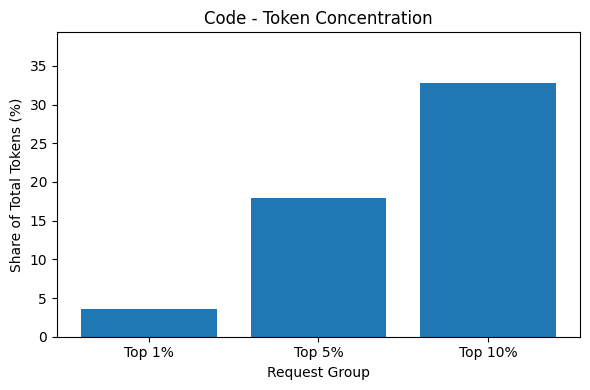


Conversation Token Concentration:
Top 1%  -> 3.76% of total tokens
Top 5%  -> 15.98% of total tokens
Top 10% -> 30.09% of total tokens


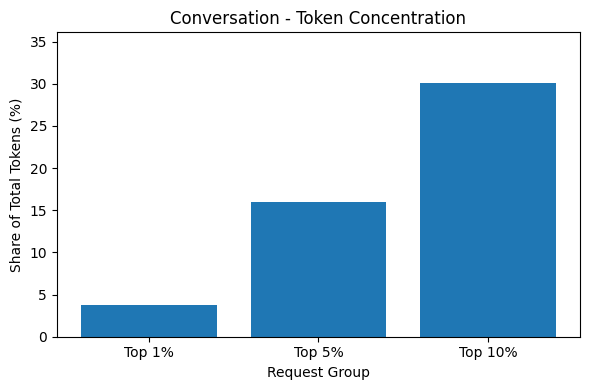


Saved token concentration summary:
/Users/meghanakoti/masterproject/masters-project/reports/eval/splitwise/azure_llm_token_concentration_summary.csv


In [5]:
# ------------------------------------------------------------
# STEP 3: Token Concentration Analysis
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt

TOKEN_CONCENTRATION_PATH = TABLE_DIR / "azure_llm_token_concentration_summary.csv"

concentration_rows = []

for name, df in [("code", code_df), ("conversation", conv_df)]:
    label = name.capitalize()

    # Ensure numeric token columns
    df["ContextTokens"] = pd.to_numeric(df["ContextTokens"], errors="coerce")
    df["GeneratedTokens"] = pd.to_numeric(df["GeneratedTokens"], errors="coerce")

    # Drop invalid token rows
    df_clean = df.dropna(subset=["ContextTokens", "GeneratedTokens"]).copy()

    # Create / refresh TotalTokens
    df_clean["TotalTokens"] = df_clean["ContextTokens"] + df_clean["GeneratedTokens"]

    # Remove invalid or zero-token rows
    df_clean = df_clean[df_clean["TotalTokens"] > 0].copy()

    if df_clean.empty:
        print(f"\n{label}: No valid token rows found. Skipping.")
        continue

    df_sorted = df_clean.sort_values("TotalTokens", ascending=False)
    total_tokens = df_clean["TotalTokens"].sum()

    top_1_n = max(1, int(0.01 * len(df_clean)))
    top_5_n = max(1, int(0.05 * len(df_clean)))
    top_10_n = max(1, int(0.10 * len(df_clean)))

    top_1 = df_sorted.head(top_1_n)["TotalTokens"].sum() / total_tokens
    top_5 = df_sorted.head(top_5_n)["TotalTokens"].sum() / total_tokens
    top_10 = df_sorted.head(top_10_n)["TotalTokens"].sum() / total_tokens

    print(f"\n{label} Token Concentration:")
    print(f"Top 1%  -> {top_1:.2%} of total tokens")
    print(f"Top 5%  -> {top_5:.2%} of total tokens")
    print(f"Top 10% -> {top_10:.2%} of total tokens")

    concentration_rows.append({
        "dataset": name,
        "total_requests": len(df_clean),
        "total_tokens": total_tokens,
        "top_1_request_count": top_1_n,
        "top_5_request_count": top_5_n,
        "top_10_request_count": top_10_n,
        "top_1_pct_share": top_1,
        "top_5_pct_share": top_5,
        "top_10_pct_share": top_10,
    })

    labels = ["Top 1%", "Top 5%", "Top 10%"]
    values = [top_1 * 100, top_5 * 100, top_10 * 100]

    plt.figure(figsize=(6, 4))
    plt.bar(labels, values)
    plt.title(f"{label} - Token Concentration")
    plt.xlabel("Request Group")
    plt.ylabel("Share of Total Tokens (%)")
    plt.ylim(0, max(values) * 1.2)
    plt.tight_layout()
    plt.show()
    plt.close()

concentration_df = pd.DataFrame(concentration_rows)
concentration_df.to_csv(TOKEN_CONCENTRATION_PATH, index=False)

print("\nSaved token concentration summary:")
print(TOKEN_CONCENTRATION_PATH)

In [6]:
# ------------------------------------------------------------
# STEP 4: Window-Level Baseline Creation
# - split request-level traces by time
# - aggregate each split to per-minute demand
# - compute train-based baseline capacities
# - save baseline summary to reports/eval/splitwise/tables
# ------------------------------------------------------------

import numpy as np
import pandas as pd

BASELINE_SUMMARY_PATH = TABLE_DIR / "azure_llm_window_baselines_summary.csv"

CODE_TRAIN_MIN_PATH = DATA_PROCESSED / "code_train_per_minute.parquet"
CODE_VAL_MIN_PATH   = DATA_PROCESSED / "code_val_per_minute.parquet"
CODE_TEST_MIN_PATH  = DATA_PROCESSED / "code_test_per_minute.parquet"

CONV_TRAIN_MIN_PATH = DATA_PROCESSED / "conversation_train_per_minute.parquet"
CONV_VAL_MIN_PATH   = DATA_PROCESSED / "conversation_val_per_minute.parquet"
CONV_TEST_MIN_PATH  = DATA_PROCESSED / "conversation_test_per_minute.parquet"


# Step 4A: ensure required derived columns exist
for df in [code_df, conv_df]:
    if "TotalTokens" not in df.columns:
        df["TotalTokens"] = df["ContextTokens"] + df["GeneratedTokens"]
    if "minute" not in df.columns:
        df["minute"] = df["TIMESTAMP"].dt.floor("min")


# Step 4B: time-based split at request level
def split_time_based_three_way(df, train_ratio=0.7, val_ratio=0.15):
    df = df.sort_values("TIMESTAMP").reset_index(drop=True)

    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()

    return train_df, val_df, test_df


# Step 4C: aggregate each split to per-minute demand
def aggregate_per_minute(df):
    return (
        df.groupby("minute")
          .agg(
              RequestCount=("TotalTokens", "size"),
              TotalContextTokens=("ContextTokens", "sum"),
              TotalGeneratedTokens=("GeneratedTokens", "sum"),
              TotalTokens=("TotalTokens", "sum"),
          )
          .sort_index()
          .reset_index()
    )


# Step 4D: compute baselines from TRAIN per-minute demand
def compute_window_baselines(per_minute_df, target_col="TotalTokens"):
    values = per_minute_df[target_col].dropna()

    return {
        "mean": values.mean(),
        "median": values.median(),
        "p90": np.percentile(values, 90),
        "p95": np.percentile(values, 95),
        "p99": np.percentile(values, 99),
    }


# Split request-level data
code_train, code_val, code_test = split_time_based_three_way(code_df)
conv_train, conv_val, conv_test = split_time_based_three_way(conv_df)

# Aggregate to per-minute demand
code_train_minute = aggregate_per_minute(code_train)
code_val_minute = aggregate_per_minute(code_val)
code_test_minute = aggregate_per_minute(code_test)

conv_train_minute = aggregate_per_minute(conv_train)
conv_val_minute = aggregate_per_minute(conv_val)
conv_test_minute = aggregate_per_minute(conv_test)

# Save intermediate window-level outputs to processed
code_train_minute.to_parquet(CODE_TRAIN_MIN_PATH, index=False)
code_val_minute.to_parquet(CODE_VAL_MIN_PATH, index=False)
code_test_minute.to_parquet(CODE_TEST_MIN_PATH, index=False)

conv_train_minute.to_parquet(CONV_TRAIN_MIN_PATH, index=False)
conv_val_minute.to_parquet(CONV_VAL_MIN_PATH, index=False)
conv_test_minute.to_parquet(CONV_TEST_MIN_PATH, index=False)

# Compute baselines from TRAIN per-minute demand
code_baselines = compute_window_baselines(code_train_minute, target_col="TotalTokens")
conv_baselines = compute_window_baselines(conv_train_minute, target_col="TotalTokens")

print("Code per-minute baselines (from TRAIN windows):")
for k, v in code_baselines.items():
    print(f"{k.upper():6} : {v:.2f}")

print("\nConversation per-minute baselines (from TRAIN windows):")
for k, v in conv_baselines.items():
    print(f"{k.upper():6} : {v:.2f}")

print("\nWindow counts:")
print(f"Code -> Train: {len(code_train_minute)}, Val: {len(code_val_minute)}, Test: {len(code_test_minute)}")
print(f"Conv -> Train: {len(conv_train_minute)}, Val: {len(conv_val_minute)}, Test: {len(conv_test_minute)}")

# Save baseline summary to reports
baseline_rows = []
for dataset_name, baselines, train_windows, val_windows, test_windows in [
    ("code", code_baselines, len(code_train_minute), len(code_val_minute), len(code_test_minute)),
    ("conversation", conv_baselines, len(conv_train_minute), len(conv_val_minute), len(conv_test_minute)),
]:
    baseline_rows.append({
        "dataset": dataset_name,
        "train_windows": train_windows,
        "val_windows": val_windows,
        "test_windows": test_windows,
        "mean": baselines["mean"],
        "median": baselines["median"],
        "p90": baselines["p90"],
        "p95": baselines["p95"],
        "p99": baselines["p99"],
    })

baseline_summary_df = pd.DataFrame(baseline_rows)
baseline_summary_df.to_csv(BASELINE_SUMMARY_PATH, index=False)

print("\nSaved processed window-level datasets:")
print(CODE_TRAIN_MIN_PATH)
print(CODE_VAL_MIN_PATH)
print(CODE_TEST_MIN_PATH)
print(CONV_TRAIN_MIN_PATH)
print(CONV_VAL_MIN_PATH)
print(CONV_TEST_MIN_PATH)

print("\nSaved baseline summary:")
print(BASELINE_SUMMARY_PATH)

Code per-minute baselines (from TRAIN windows):
MEAN   : 440755.59
MEDIAN : 358831.00
P90    : 940370.60
P95    : 1062822.20
P99    : 1223628.20

Conversation per-minute baselines (from TRAIN windows):
MEAN   : 489624.28
MEDIAN : 458076.00
P90    : 699643.40
P95    : 734202.70
P99    : 778249.06

Window counts:
Code -> Train: 29, Val: 8, Test: 10
Conv -> Train: 39, Val: 10, Test: 13

Saved processed window-level datasets:
/Users/meghanakoti/masterproject/masters-project/data/raw/azure/processed/code_train_per_minute.parquet
/Users/meghanakoti/masterproject/masters-project/data/raw/azure/processed/code_val_per_minute.parquet
/Users/meghanakoti/masterproject/masters-project/data/raw/azure/processed/code_test_per_minute.parquet
/Users/meghanakoti/masterproject/masters-project/data/raw/azure/processed/conversation_train_per_minute.parquet
/Users/meghanakoti/masterproject/masters-project/data/raw/azure/processed/conversation_val_per_minute.parquet
/Users/meghanakoti/masterproject/masters-pr

In [7]:
# ------------------------------------------------------------
# STEP 5A: Window-Based Workload Characterization (10s)
# - aggregate request traces into 10-second windows
# - save intermediate window datasets to processed
# ------------------------------------------------------------

import pandas as pd

CODE_TRAIN_10S_PATH = DATA_PROCESSED / "code_train_10s_windows.parquet"
CODE_VAL_10S_PATH   = DATA_PROCESSED / "code_val_10s_windows.parquet"
CODE_TEST_10S_PATH  = DATA_PROCESSED / "code_test_10s_windows.parquet"

CONV_TRAIN_10S_PATH = DATA_PROCESSED / "conversation_train_10s_windows.parquet"
CONV_VAL_10S_PATH   = DATA_PROCESSED / "conversation_val_10s_windows.parquet"
CONV_TEST_10S_PATH  = DATA_PROCESSED / "conversation_test_10s_windows.parquet"


def prepare_time_windows(df, window="10s"):
    df = df.copy()

    # Ensure timestamp is datetime
    df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"])

    # Ensure TotalTokens exists
    if "TotalTokens" not in df.columns:
        df["TotalTokens"] = df["ContextTokens"] + df["GeneratedTokens"]

    # Create time windows
    df["Window"] = df["TIMESTAMP"].dt.floor(window)

    # Aggregate window-level workload
    per_window = (
        df.groupby("Window")
          .agg(
              RequestCount=("TotalTokens", "size"),
              TotalContextTokens=("ContextTokens", "sum"),
              TotalGeneratedTokens=("GeneratedTokens", "sum"),
              TotalTokens=("TotalTokens", "sum"),
              AvgContextTokens=("ContextTokens", "mean"),
              AvgGeneratedTokens=("GeneratedTokens", "mean"),
              AvgTotalTokens=("TotalTokens", "mean"),
              MaxContextTokens=("ContextTokens", "max"),
              MaxGeneratedTokens=("GeneratedTokens", "max"),
              MaxTotalTokens=("TotalTokens", "max"),
          )
          .sort_index()
          .reset_index()
    )

    return per_window


# Apply 10-second window aggregation to all splits
code_train_window = prepare_time_windows(code_train, window="10s")
code_val_window = prepare_time_windows(code_val, window="10s")
code_test_window = prepare_time_windows(code_test, window="10s")

conv_train_window = prepare_time_windows(conv_train, window="10s")
conv_val_window = prepare_time_windows(conv_val, window="10s")
conv_test_window = prepare_time_windows(conv_test, window="10s")

# Save intermediate outputs
code_train_window.to_parquet(CODE_TRAIN_10S_PATH, index=False)
code_val_window.to_parquet(CODE_VAL_10S_PATH, index=False)
code_test_window.to_parquet(CODE_TEST_10S_PATH, index=False)

conv_train_window.to_parquet(CONV_TRAIN_10S_PATH, index=False)
conv_val_window.to_parquet(CONV_VAL_10S_PATH, index=False)
conv_test_window.to_parquet(CONV_TEST_10S_PATH, index=False)

# Quick checks
print("Code train windows:", code_train_window.shape)
print("Code validation windows:", code_val_window.shape)
print("Code test windows:", code_test_window.shape)

print("\nConversation train windows:", conv_train_window.shape)
print("Conversation validation windows:", conv_val_window.shape)
print("Conversation test windows:", conv_test_window.shape)

print("\nCode test window sample:")
print(code_test_window.head())

print("\nConversation test window sample:")
print(conv_test_window.head())

print("\nSaved 10-second window datasets:")
print(CODE_TRAIN_10S_PATH)
print(CODE_VAL_10S_PATH)
print(CODE_TEST_10S_PATH)
print(CONV_TRAIN_10S_PATH)
print(CONV_VAL_10S_PATH)
print(CONV_TEST_10S_PATH)

Code train windows: (90, 11)
Code validation windows: (24, 11)
Code test windows: (24, 11)

Conversation train windows: (230, 11)
Conversation validation windows: (52, 11)
Conversation test windows: (71, 11)

Code test window sample:
               Window  RequestCount  TotalContextTokens  TotalGeneratedTokens  \
0 2023-11-16 18:59:00            48              118249                  2000   
1 2023-11-16 18:59:10            77              148558                  2237   
2 2023-11-16 18:59:40            80              112796                  2644   
3 2023-11-16 18:59:50            16               38604                   360   
4 2023-11-16 19:00:00            76              143309                  2193   

   TotalTokens  AvgContextTokens  AvgGeneratedTokens  AvgTotalTokens  \
0       120249       2463.520833           41.666667     2505.187500   
1       150795       1929.324675           29.051948     1958.376623   
2       115440       1409.950000           33.050000     1443.0

In [8]:
# ------------------------------------------------------------
# STEP 5B: Window-Level Baselines from TRAIN 10s Windows
# - compute fixed baseline capacities from TRAIN windows
# - summarize workload statistics for code and conversation
# - save key baseline summary to reports/eval/splitwise/tables
# ------------------------------------------------------------

import numpy as np
import pandas as pd

WINDOW_BASELINE_SUMMARY_PATH = TABLE_DIR / "azure_llm_10s_window_baselines_summary.csv"

def compute_window_baselines(per_window_df, target_col="TotalTokens"):
    values = per_window_df[target_col].dropna()

    return {
        "mean": values.mean(),
        "median": values.median(),
        "p90": np.percentile(values, 90),
        "p95": np.percentile(values, 95),
        "p99": np.percentile(values, 99),
        "max": values.max(),
    }

# Compute baselines from TRAIN 10s windows
code_window_baselines = compute_window_baselines(code_train_window, target_col="TotalTokens")
conv_window_baselines = compute_window_baselines(conv_train_window, target_col="TotalTokens")

print("Code 10s window baselines (from TRAIN):")
for k, v in code_window_baselines.items():
    print(f"{k.upper():6} : {v:.2f}")

print("\nConversation 10s window baselines (from TRAIN):")
for k, v in conv_window_baselines.items():
    print(f"{k.upper():6} : {v:.2f}")

# Save summary
baseline_rows = [
    {
        "dataset": "code",
        "train_windows": len(code_train_window),
        "val_windows": len(code_val_window),
        "test_windows": len(code_test_window),
        "mean": code_window_baselines["mean"],
        "median": code_window_baselines["median"],
        "p90": code_window_baselines["p90"],
        "p95": code_window_baselines["p95"],
        "p99": code_window_baselines["p99"],
        "max": code_window_baselines["max"],
    },
    {
        "dataset": "conversation",
        "train_windows": len(conv_train_window),
        "val_windows": len(conv_val_window),
        "test_windows": len(conv_test_window),
        "mean": conv_window_baselines["mean"],
        "median": conv_window_baselines["median"],
        "p90": conv_window_baselines["p90"],
        "p95": conv_window_baselines["p95"],
        "p99": conv_window_baselines["p99"],
        "max": conv_window_baselines["max"],
    }
]

window_baseline_summary_df = pd.DataFrame(baseline_rows)
window_baseline_summary_df.to_csv(WINDOW_BASELINE_SUMMARY_PATH, index=False)

print("\nSaved 10s window baseline summary:")
print(WINDOW_BASELINE_SUMMARY_PATH)

Code 10s window baselines (from TRAIN):
MEAN   : 142021.24
MEDIAN : 121368.50
P90    : 262952.60
P95    : 314507.55
P99    : 483749.82
MAX    : 884305.00

Conversation 10s window baselines (from TRAIN):
MEAN   : 83023.25
MEDIAN : 78068.50
P90    : 121973.80
P95    : 131490.35
P99    : 147536.99
MAX    : 180517.00

Saved 10s window baseline summary:
/Users/meghanakoti/masterproject/masters-project/reports/eval/splitwise/azure_llm_10s_window_baselines_summary.csv


In [9]:
# ------------------------------------------------------------
# STEP 6: Core Evaluation of Fixed Baselines on 10s Windows
# - apply fixed train-derived baselines to val/test windows
# - compute reliability + efficiency metrics
# - save summary tables to reports/eval/splitwise/tables

import pandas as pd
import numpy as np

# ---------------------------
# Output paths
# ---------------------------
CODE_VAL_EVAL_PATH = DATA_PROCESSED / "code_val_10s_evaluated.parquet"
CODE_TEST_EVAL_PATH = DATA_PROCESSED / "code_test_10s_evaluated.parquet"
CONV_VAL_EVAL_PATH = DATA_PROCESSED / "conversation_val_10s_evaluated.parquet"
CONV_TEST_EVAL_PATH = DATA_PROCESSED / "conversation_test_10s_evaluated.parquet"

VAL_SUMMARY_PATH = TABLE_DIR / "azure_llm_10s_validation_summary.csv"
TEST_SUMMARY_PATH = TABLE_DIR / "azure_llm_10s_test_summary.csv"

baseline_names = ["mean", "median", "p90", "p95", "p99", "max"]

# ---------------------------
# Helper: evaluate one window dataframe
# ---------------------------
def evaluate_fixed_baselines(per_window_df, baselines, target_col="TotalTokens"):
    df = per_window_df.copy()

    actual = df[target_col].astype(float)

    for b in baseline_names:
        capacity = float(baselines[b])

        df[f"capacity_{b}"] = capacity
        df[f"shortfall_{b}"] = np.maximum(actual - capacity, 0.0)
        df[f"slack_{b}"] = capacity - actual
        df[f"waste_{b}"] = np.maximum(capacity - actual, 0.0)
        df[f"violation_{b}"] = (actual > capacity).astype(int)
        df[f"safe_{b}"] = (actual <= capacity).astype(int)

        # relative forms
        denom_actual = actual.replace(0, np.nan)
        denom_capacity = capacity if capacity != 0 else np.nan

        df[f"relative_shortfall_{b}"] = df[f"shortfall_{b}"] / denom_actual
        df[f"relative_waste_{b}"] = df[f"waste_{b}"] / denom_capacity if pd.notna(denom_capacity) else np.nan
        df[f"utilization_{b}"] = actual / denom_capacity if pd.notna(denom_capacity) else np.nan

    return df

# ---------------------------
# Helper: summarize one evaluated dataframe
# ---------------------------
def summarize_evaluation(df, dataset_name, split_name):
    rows = []

    for b in baseline_names:
        rows.append({
            "dataset": dataset_name,
            "split": split_name,
            "baseline": b,
            "windows": len(df),
            "avg_demand": df["TotalTokens"].mean(),
            "median_demand": df["TotalTokens"].median(),
            "fixed_capacity": df[f"capacity_{b}"].iloc[0],
            "violation_rate": df[f"violation_{b}"].mean(),
            "safe_window_rate": df[f"safe_{b}"].mean(),
            "avg_shortfall": df[f"shortfall_{b}"].mean(),
            "avg_waste": df[f"waste_{b}"].mean(),
            "avg_slack": df[f"slack_{b}"].mean(),
            "avg_relative_shortfall": df[f"relative_shortfall_{b}"].mean(),
            "avg_relative_waste": df[f"relative_waste_{b}"].mean(),
            "avg_utilization": df[f"utilization_{b}"].mean(),
            "median_utilization": df[f"utilization_{b}"].median(),
        })

    return pd.DataFrame(rows)

# ---------------------------
# Apply baselines
# ---------------------------
code_val_eval = evaluate_fixed_baselines(code_val_window, code_window_baselines)
code_test_eval = evaluate_fixed_baselines(code_test_window, code_window_baselines)

conv_val_eval = evaluate_fixed_baselines(conv_val_window, conv_window_baselines)
conv_test_eval = evaluate_fixed_baselines(conv_test_window, conv_window_baselines)

# ---------------------------
# Save detailed evaluated windows
# ---------------------------
code_val_eval.to_parquet(CODE_VAL_EVAL_PATH, index=False)
code_test_eval.to_parquet(CODE_TEST_EVAL_PATH, index=False)

conv_val_eval.to_parquet(CONV_VAL_EVAL_PATH, index=False)
conv_test_eval.to_parquet(CONV_TEST_EVAL_PATH, index=False)

# ---------------------------
# Build summaries
# ---------------------------
val_summary = pd.concat([
    summarize_evaluation(code_val_eval, "code", "validation"),
    summarize_evaluation(conv_val_eval, "conversation", "validation"),
], ignore_index=True)

test_summary = pd.concat([
    summarize_evaluation(code_test_eval, "code", "test"),
    summarize_evaluation(conv_test_eval, "conversation", "test"),
], ignore_index=True)

# Save summaries
val_summary.to_csv(VAL_SUMMARY_PATH, index=False)
test_summary.to_csv(TEST_SUMMARY_PATH, index=False)

# ---------------------------
# Display
# ---------------------------
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

print("\nValidation summary:")
print(val_summary)

print("\nTest summary:")
print(test_summary)

print("\nSaved evaluated window datasets:")
print(CODE_VAL_EVAL_PATH)
print(CODE_TEST_EVAL_PATH)
print(CONV_VAL_EVAL_PATH)
print(CONV_TEST_EVAL_PATH)

print("\nSaved summary tables:")
print(VAL_SUMMARY_PATH)
print(TEST_SUMMARY_PATH)


Validation summary:
         dataset       split baseline  windows  avg_demand  median_demand  \
0           code  validation     mean       24 113232.8333     98000.0000   
1           code  validation   median       24 113232.8333     98000.0000   
2           code  validation      p90       24 113232.8333     98000.0000   
3           code  validation      p95       24 113232.8333     98000.0000   
4           code  validation      p99       24 113232.8333     98000.0000   
5           code  validation      max       24 113232.8333     98000.0000   
6   conversation  validation     mean       52  70984.9808     70074.5000   
7   conversation  validation   median       52  70984.9808     70074.5000   
8   conversation  validation      p90       52  70984.9808     70074.5000   
9   conversation  validation      p95       52  70984.9808     70074.5000   
10  conversation  validation      p99       52  70984.9808     70074.5000   
11  conversation  validation      max       52  70984.9

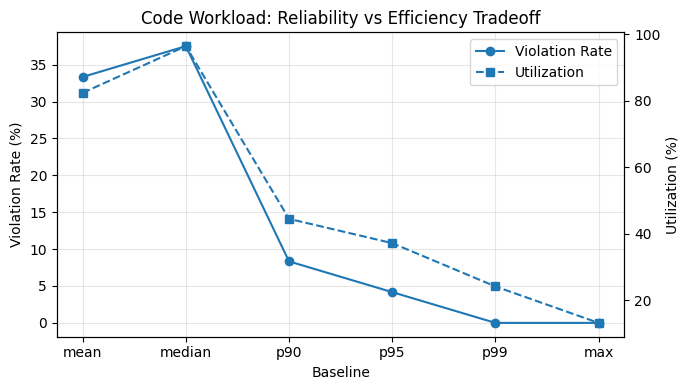

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/meghanakoti/masterproject/masters-project/reports/eval/splitwise/azure_llm_10s_test_summary.csv")

baseline_order = ["mean", "median", "p90", "p95", "p99", "max"]
df["baseline"] = pd.Categorical(df["baseline"], categories=baseline_order, ordered=True)
df = df.sort_values(["dataset", "baseline"])

code_df = df[df["dataset"] == "code"]

fig, ax1 = plt.subplots(figsize=(7, 4))

# ---- Left axis: Violation ----
ax1.plot(code_df["baseline"], code_df["violation_rate"] * 100, marker="o", label="Violation Rate")
ax1.set_xlabel("Baseline")
ax1.set_ylabel("Violation Rate (%)")
ax1.tick_params(axis='y')

# ---- Right axis: Utilization ----
ax2 = ax1.twinx()
ax2.plot(code_df["baseline"], code_df["avg_utilization"] * 100, marker="s", linestyle="--", label="Utilization")
ax2.set_ylabel("Utilization (%)")
ax2.tick_params(axis='y')

# Title + grid
plt.title("Code Workload: Reliability vs Efficiency Tradeoff")
ax1.grid(True, alpha=0.3)

# Legend (combine both)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2)

plt.tight_layout()
plt.savefig("/Users/meghanakoti/masterproject/masters-project/reports/eval/splitwise/figures/code_relaibilitytradeoff.png", dpi=200)
plt.show()